# 기초통계 통합 프로젝트
## Part 1. 고객 구매 데이터 기술통계 및 이상치 분석

### 시나리오

온라인 쇼핑몰 데이터 분석팀은 고객 구매 데이터를 활용하여 고객의 전반적인 구매 특성을 파악하려고 합니다.

분석팀은 먼저 다음 내용을 확인해야 합니다.

- 고객의 평균적인 구매금액과 구매수량
- 고객 데이터가 얼마나 넓게 퍼져 있는지
- 구매금액 분포가 한쪽으로 치우쳐 진 구조인지
- 일반적인 고객과 차이가 큰 구매 데이터가 있는지

Part 1에서는 주요 기술통계량과 그래프를 이용하여 고객 구매 데이터의 기본 특성을 점검합니다.
이 결과는 이후 표본 분석, 상관관계 분석, 회귀예측에 공통으로 활용합니다.

### 과제 목표

- 평균, 중앙값, 분산, 표준편차를 계산할 수 있습니다.
- Q1, Q2, Q3를 계산하여 데이터의 위치를 확인할 수 있습니다.
- 히스토그램과 박스플롯으로 구매금액 분포를 확인할 수 있습니다.
- IQR 기준으로 이상치 후보를 찾을 수 있습니다.
- 계산 결과를 고객 구매 특성과 연결하여 설명할 수 있습니다.

### 사용 환경

- 결과물: `.ipynb` 파일 1개
- 사용 언어: Python 3.X
- 사용 라이브러리: pandas, matplotlib
- 사용 데이터: `online_shopping_customer_data.csv`


## 제공 코드. 고객 데이터 불러오기

아래 코드는 준비 코드이며 평가 대상이 아닙니다.

분석 대상 컬럼의 결측치가 있는 행을 제거하여 `analysis_df`를 생성합니다.
이후 Part에서도 동일한 전처리 기준을 사용합니다.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

DATA_FILE = "online_shopping_customer_data.csv"

df = pd.read_csv(DATA_FILE)

analysis_columns = ["PurchaseAmount", "PurchaseQty", "Age", "ReviewScore"]

analysis_df = df.dropna(subset=analysis_columns).copy()

print("전체 데이터 크기:", df.shape)
print("분석 데이터 크기:", analysis_df.shape)
print("분석 대상 컬럼:", analysis_columns)

analysis_df[analysis_columns].head()


전체 데이터 크기: (500, 13)
분석 데이터 크기: (486, 13)
분석 대상 컬럼: ['PurchaseAmount', 'PurchaseQty', 'Age', 'ReviewScore']


,PurchaseAmount,PurchaseQty,Age,ReviewScore
0,86900.0,4,41,4.7
1,287500.0,7,27,4.9
2,242100.0,5,46,3.9
3,300500.0,5,48,5.0
4,171400.0,2,19,4.1


# 문제 1. 주요 기술통계량 계산

## 업무 상황

분석팀은 고객의 평균적인 구매 수준과 데이터의 분포를 한눈에 확인할 수 있는 요약표를 만들려고 합니다.

## 요구사항

1. `PurchaseAmount`, `PurchaseQty`, `Age`, `ReviewScore`의 평균을 계산합니다.
2. 각 컬럼의 중앙값을 계산합니다.
3. 각 컬럼의 분산과 표준편차를 계산합니다.
4. Q1, Q2, Q3를 계산합니다.
5. 계산 결과를 하나의 표로 정리하여 출력합니다.
6. `PurchaseAmount`의 평균과 중앙값을 비교합니다.


In [18]:
# 문제 1 코드를 작성하세요.
pd.options.display.float_format = '{:.2f}'.format

result = pd.DataFrame({
    "PurchaseAmount":[
        analysis_df['PurchaseAmount'].mean(),
        analysis_df['PurchaseAmount'].median(),
        analysis_df['PurchaseAmount'].var(),
        analysis_df['PurchaseAmount'].std(),
        analysis_df['PurchaseAmount'].quantile(0.25),
        analysis_df['PurchaseAmount'].quantile(0.5),
        analysis_df['PurchaseAmount'].quantile(0.75)
    ],
    "PurchaseQty":[
        analysis_df['PurchaseQty'].mean(),
        analysis_df['PurchaseQty'].median(),
        analysis_df['PurchaseQty'].var(),
        analysis_df['PurchaseQty'].std(),
        analysis_df['PurchaseQty'].quantile(0.25),
        analysis_df['PurchaseQty'].quantile(0.5),
        analysis_df['PurchaseQty'].quantile(0.75)
    ],
    "Age":[
        analysis_df['Age'].mean(),
        analysis_df['Age'].median(),
        analysis_df['Age'].var(),
        analysis_df['Age'].std(),
        analysis_df['Age'].quantile(0.25),
        analysis_df['Age'].quantile(0.5),
        analysis_df['Age'].quantile(0.75)
    ],
    "ReviewScore":[
        analysis_df['ReviewScore'].mean(),
        analysis_df['ReviewScore'].median(),
        analysis_df['ReviewScore'].var(),
        analysis_df['ReviewScore'].std(),
        analysis_df['ReviewScore'].quantile(0.25),
        analysis_df['ReviewScore'].quantile(0.5),
        analysis_df['ReviewScore'].quantile(0.75)
    ]
}, index = ['평균', '중앙값', '분산', '표준편차', 'Q1', 'Q2', 'Q3'])

display(result)

print('Purchas Amount의 평균과 중앙값 차이:', round(analysis_df['PurchaseAmount'].mean() - analysis_df['PurchaseAmount'].median(), 2))


,PurchaseAmount,PurchaseQty,Age,ReviewScore
평균,229961.52,3.84,37.94,3.93
중앙값,216450.00,4.00,38.00,3.90
분산,14143579609.22,4.05,97.69,0.42
표준편차,118926.78,2.01,9.88,0.65
Q1,158225.00,2.00,31.00,3.50
Q2,216450.00,4.00,38.00,3.90
Q3,280525.00,5.00,44.00,4.40


Purchas Amount의 평균과 중앙값 차이: 13511.52


# 문제 2. 구매금액 분포와 이상치 후보 확인

## 업무 상황

고객 구매금액이 특정 구간에 집중되어 있는지 확인하고,
일반적인 고객과 차이가 큰 고액 또는 저액 구매 데이터를 찾으려고 합니다.

## 요구사항

1. `PurchaseAmount`의 히스토그램을 생성합니다.
2. `PurchaseAmount`의 박스플롯을 생성합니다.
3. Q1, Q3, IQR을 계산합니다.
4. IQR 기준의 하한값과 상한값을 계산합니다.
5. 하한값보다 작거나 상한값보다 큰 데이터를 이상치 후보로 추출합니다.
6. 이상치 후보의 개수와 `CustomerID`, `PurchaseAmount`를 출력합니다.

## IQR 기준

- 하한값: `Q1 - 1.5 × IQR`
- 상한값: `Q3 + 1.5 × IQR`


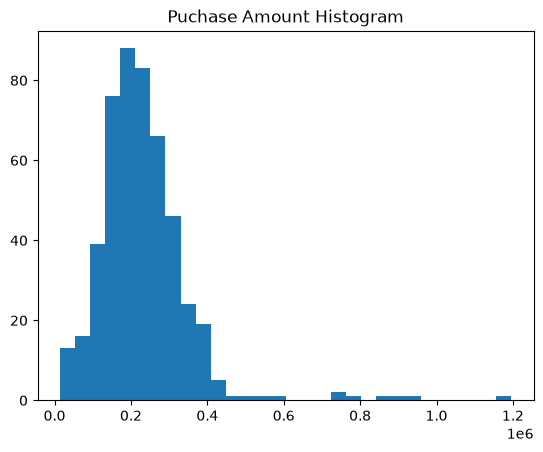

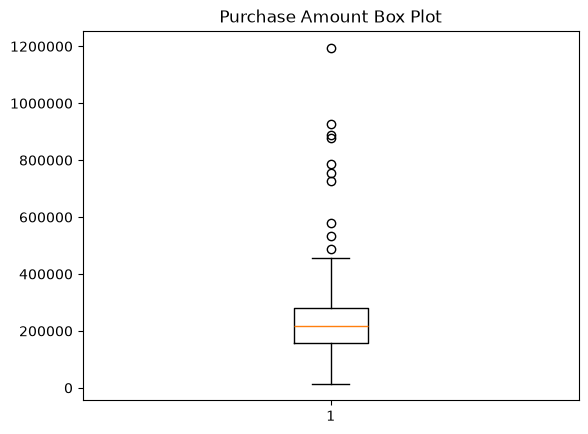

하한값: -25225.0
상한값: 463975.0
이상치 후보의 개수: 10


,CustomerID,PurchaseAmount
31,CUST0032,788100.00
34,CUST0035,876500.00
77,CUST0078,889400.00
177,CUST0178,580400.00
179,CUST0180,489400.00
281,CUST0282,534500.00
299,CUST0300,1195500.00
319,CUST0320,925400.00
368,CUST0369,755900.00
390,CUST0391,725200.00


In [29]:
# 문제 2 코드를 작성하세요.
plt.hist(analysis_df['PurchaseAmount'], bins = 30)
plt.title('Puchase Amount Histogram')
plt.show()

plt.boxplot(analysis_df['PurchaseAmount'], orientation = 'vertical')
plt.ticklabel_format(style='plain', axis='y')
plt.title('Purchase Amount Box Plot')
plt.show()

q1 = analysis_df['PurchaseAmount'].quantile(0.25)
q3 = analysis_df['PurchaseAmount'].quantile(0.75)
IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print('하한값:', lower_bound)
print('상한값:', upper_bound)

outliers = analysis_df[
    (analysis_df['PurchaseAmount'] < lower_bound) |
    (analysis_df['PurchaseAmount'] > upper_bound)
]

print('이상치 후보의 개수:', len(outliers))
display(outliers[['CustomerID', 'PurchaseAmount']])


# 문제 3. 고객 구매 특성 해석

## 업무 상황

분석팀은 계산 결과를 마케팅 담당자가 이해할 수 있도록
구매금액의 기본적인 분포 특성으로 정리해야 합니다.

## 필수 요구사항

다음 내용을 포함하여 3문장 이상 작성합니다.

1. `PurchaseAmount`의 평균과 중앙값 중 어떤 값이 더 큰지 설명합니다.
2. 히스토그램과 박스플롯에서 확인한 구매금액 분포의 특징을 설명합니다.
3. IQR 기준으로 탐지된 이상치 후보의 개수를 설명합니다.


In [ ]:
# 문제 3 해석에 필요한 값을 출력하고, 아래 마크다운 셀에 해석을 작성하세요.


# 심화 문제. 이상치 후보의 업무적 의미 분석

이 문제는 필수 문제가 아니며, **심화 문제**입니다.

## 업무 상황

IQR 기준을 벗어난 구매금액이 발견되었지만,
해당 고객을 분석 데이터에서 바로 제거해도 되는지는 추가 확인이 필요합니다.

## 심화 요구사항

다음 내용을 포함하여 3문장 이상 작성합니다.

1. 이상치 후보가 입력 오류가 아닌 정상적인 고액 구매일 수 있는 사례를 제시합니다.
2. 이상치 후보를 바로 삭제하면 안 되는 이유를 설명합니다.
3. 이상치 처리 전에 추가로 확인해야 할 고객 또는 구매 정보를 작성합니다.


In [ ]:
# 심화 문제 해석에 필요한 이상치 후보를 확인하세요.


# 제출 결과물

| 결과물 | 제출 내용 |
|---|---|
| 기술통계 요약표 | 평균, 중앙값, 분산, 표준편차, Q1, Q2, Q3 |
| 구매금액 분포 | 히스토그램과 박스플롯 |
| 이상치 탐지 결과 | IQR 기준, 이상치 후보 개수와 고객 정보 |
| 기본 해석 | 구매금액 분포와 이상치 후보 개수 설명 |
| 심화 해석 | 이상치의 업무적 의미와 처리 전 확인 사항(선택) |

# 제출 전 체크리스트

## 필수 문제

- [ ] 평균과 중앙값을 계산했습니다.
- [ ] 분산과 표준편차를 계산했습니다.
- [ ] Q1, Q2, Q3를 계산했습니다.
- [ ] 기술통계량을 하나의 표로 정리했습니다.
- [ ] 히스토그램과 박스플롯을 생성했습니다.
- [ ] IQR 기준으로 이상치 후보를 찾았습니다.
- [ ] 구매금액 분포와 이상치 후보 개수를 설명했습니다.

## 심화 문제

- [ ] 이상치 후보가 정상적인 고액 구매일 수 있는 사례를 작성했습니다.
- [ ] 이상치를 바로 삭제하면 안 되는 이유를 설명했습니다.
- [ ] 이상치 처리 전에 확인할 정보를 작성했습니다.
